# Component: Greenland Ice Sheet

This notebook calibrates, validates, and projects the Greenland ice sheet
contribution to GMSL. The SMB and discharge components are treated as
physically independent processes with distinct forcings, calibration data,
and projection methods.

**Surface Mass Balance (SMB):**
- Historical: Mouginot (2019) RACMO-derived SMB used directly as observations
- Projections: RCM-derived C_T sensitivities with inter-RCM structural uncertainty
- NOT fit to temperature (justified exception to data-only approach — see §2a)
- Validated against GRACE − D implied SMB (RCM-independent)

**Ice Discharge (D):**
- Calibrated: ODE model forced by EN4/Argo subsurface ocean T (200–500 m)
- Mouginot (2019) discharge observations for calibration; Mankoff withheld for validation
- Surface-to-ocean transfer function for projecting under SSP scenarios

Total Greenland: H_GrIS = H_SMB + H_D

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

plt.style.use('seaborn-v0_8-poster')

sys.path.insert(0, '.')
from slr_data_readers import read_berkeley_earth, read_berkeley_earth_gridded
from slr_forecast.readers.ice_sheets import read_mouginot2019_greenland
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    fit_bayesian_greenland_discharge, solve_twolayer_ode,
    calibrate_exponential_prior, check_convergence,
    prepare_mouginot_components, prepare_mankoff_components,
)
from component_analysis import (
    fit_ocean_transfer_function, project_ocean_temperature,
)
from component_projections import (
    project_greenland_joint_ensemble,
    read_ipcc_component_nc, ipcc_extract,
)
from smb_projections import (
    SMBSensitivity, GREENLAND_SMB, project_smb_ensemble,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)
from component_io import save_greenland, load_component

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'
RESULTS_H5 = '../data/processed/component_results.h5'

BASELINE_YEAR = 2005.0
N_SAMPLES = 2000
AA = 2.58  # Arctic amplification factor
GT_TO_M_SLE = 1.0 / 362500.0

# ── Set to True to rerun fits and overwrite cached results ──
# Automatically enabled if the HDF5 cache is missing or has no greenland group.
RERUN_FITS = False

def _greenland_cached():
    """Check whether component_results.h5 contains a greenland group."""
    if not os.path.exists(RESULTS_H5):
        return False
    with h5py.File(RESULTS_H5, 'r') as f:
        return 'greenland' in f

if not RERUN_FITS and not _greenland_cached():
    RERUN_FITS = True
    print('No cached greenland results found — setting RERUN_FITS = True')

print('Imports OK')
print(f'RERUN_FITS = {RERUN_FITS}')

No cached greenland results found — setting RERUN_FITS = True
Imports OK
RERUN_FITS = True


## 1. Data Loading

In [2]:
# ── Greenland regional temperature (Berkeley Earth gridded) ──
# Uses Greenland regional T (not GMST) because SMB and discharge respond
# to local climate. Arctic amplification makes Greenland T ~2–3× GMST.
GRIDDED_PATH = f'{RAW_DIR}/gmst/berkEarth_Global_TAVG_Gridded_1deg.nc'
df_gr_temp = read_berkeley_earth_gridded(GRIDDED_PATH)  # defaults to Greenland box
gr_temp_raw = df_gr_temp['temperature'].values
gr_time_raw = df_gr_temp['decimal_year'].values

# Rebaseline to 1995–2005 (consistent with IPCC AR6 baseline period)
bl_mask = (gr_time_raw >= 1995.0) & (gr_time_raw < 2006.0)
gr_temp_monthly = gr_temp_raw - np.nanmean(gr_temp_raw[bl_mask])
valid_gr = np.isfinite(gr_temp_monthly)
gr_temp_monthly = gr_temp_monthly[valid_gr]
gr_time_monthly = gr_time_raw[valid_gr]

# ── Berkeley Earth GMST (for SSP projections and SMB sensitivity in GMST frame) ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

# ── Ocean temperature (EN4 200–500 m, Greenland peripheral waters) ──
# Subsurface T at 200–500 m depth, 58–80°N / 75–5°W. Forces the discharge ODE:
# ocean warming drives calving-front retreat and grounding-line migration.
try:
    df_en4 = pd.read_hdf(H5_PATH, key='harmonized/df_en4_greenland_200_500m')
except KeyError:
    df_en4 = pd.read_csv(f'{RAW_DIR}/../processed/en4_greenland_peripheral_200_500m.csv')
    df_en4['decimal_year'] = df_en4['year'] + (df_en4['month'] - 0.5) / 12

T_ocean_monthly = df_en4['temperature'].values
time_ocean_monthly = df_en4['decimal_year'].values
bl_oc = (time_ocean_monthly >= 1995) & (time_ocean_monthly <= 2005)
T_ocean_monthly = T_ocean_monthly - np.nanmean(T_ocean_monthly[bl_oc])

# ── Mankoff SMB + discharge (withheld for validation; Mouginot used for calibration) ──
mankoff_comp = prepare_mankoff_components(
    f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv',
    baseline_window=(1995, 2005), start_year=1972)

print(f'Greenland T: {gr_time_monthly[0]:.0f}–{gr_time_monthly[-1]:.0f}')
print(f'Ocean T: {time_ocean_monthly[0]:.0f}–{time_ocean_monthly[-1]:.0f}')
print(f'Mankoff SMB: {mankoff_comp["time_smb"][0]:.0f}–{mankoff_comp["time_smb"][-1]:.0f}')
print(f'Mankoff Dyn: {mankoff_comp["time_dyn"][0]:.0f}–{mankoff_comp["time_dyn"][-1]:.0f}')

Greenland T: 1850–2026
Ocean T: 1970–2021
Mankoff SMB: 1972–2023
Mankoff Dyn: 1972–2023


## 2a. SMB Approach: RCM-Derived Sensitivities

Greenland SMB is NOT fit to temperature. The Mouginot SMB data is RACMO
output — fitting a polynomial to reproduce RACMO would be circular. Instead:

- **Historical:** Use RACMO-derived SMB directly from Mouginot (1972–2018)
- **Projections:** Use RCM-derived C_T with inter-RCM structural uncertainty

**Why this exception to the data-only approach:**
Greenland's ablation zone has no in situ weather stations. Annual mean
temperature explains only 18% of interannual SMB variance (R² = 0.18 from
GRACE − D analysis). The processes driving melt (surface energy balance,
albedo feedback, refreezing capacity) require spatially resolved atmospheric
modeling. Using the range of RCM values with inter-RCM spread as structural
uncertainty is more principled than a poorly constrained regression.

**C_T values (per °C GMST, from multiple RCMs):**
- Central: −200 Gt/yr/°C (mean of MAR, RACMO, HIRHAM × AA)
- σ: 80 Gt/yr/°C (inter-RCM spread ~factor 1.8, Glaude et al. 2024)
- Quadratic: −50 Gt/yr/°C² (ablation zone expansion, Noël et al. 2021)
- Constraint: SMB → 0 at ~2.7°C GMST (Noël et al. 2021)

**Validation:** GRACE − D implied SMB (scripts/grace_minus_discharge_smb.py)
correlates 0.89 with RACMO SMB, confirming that the RCM captures the
aggregate signal correctly.

In [3]:
# ── SMB sensitivity from RCM literature ──
# SMB is NOT fit to temperature. Instead we use RCM-derived sensitivities
# (C_T in Gt/yr/°C GMST) with inter-RCM structural uncertainty.
# Rationale: Greenland ablation zone has no in situ weather stations;
# annual mean T explains only ~18% of interannual SMB variance.
# RCMs compute full energy balance — a polynomial in T cannot replace that.
print('Greenland SMB sensitivity (GREENLAND_SMB from smb_projections.py):')
print(f'  C_T  = {GREENLAND_SMB.C_T:.0f} ± {GREENLAND_SMB.C_T_sigma:.0f} Gt/yr/°C GMST')
print(f'  C_T² = {GREENLAND_SMB.C_T2:.0f} ± {GREENLAND_SMB.C_T2_sigma:.0f} Gt/yr/°C² GMST')
print(f'  Reference: {GREENLAND_SMB.reference}')
print(f'  In mm SLE/yr/°C: {GREENLAND_SMB.C_T * GT_TO_M_SLE * M_TO_MM:.3f}')

# ── Historical SMB from Mouginot (RACMO-derived, used as observations) ──
# These are passed through as fixed data in the discharge fit — not calibrated.
mou_comp = prepare_mouginot_components(
    read_mouginot2019_greenland(f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx'),
    baseline_window=(1995, 2005))

print(f'\nMouginot SMB (RACMO-derived, used as observations):')
print(f'  Period: {mou_comp["time_smb"][0]:.0f}–{mou_comp["time_smb"][-1]:.0f} '
      f'({len(mou_comp["time_smb"])} pts)')
print(f'  Cumulative at {mou_comp["time_smb"][-1]:.0f}: '
      f'{mou_comp["H_smb"][-1]*M_TO_MM:.1f} mm SLE')

# ── GRACE − D implied SMB (RCM-independent validation) ──
# Implied SMB = GRACE total mass balance − satellite discharge.
# Provides an observational lower bound on C_T.
grace_d_path = '../data/processed/greenland_implied_smb.csv'
if os.path.exists(grace_d_path):
    df_grace_d = pd.read_csv(grace_d_path)
    print(f'\nGRACE − D implied SMB validation:')
    print(f'  Period: {df_grace_d["year"].iloc[0]:.0f}–{df_grace_d["year"].iloc[-1]:.0f}')
    if 'rcm_smb_rate_slr' in df_grace_d.columns:
        overlap = df_grace_d.dropna(subset=['rcm_smb_rate_slr'])
        r = overlap['implied_smb_rate_slr'].corr(overlap['rcm_smb_rate_slr'])
        diff = (overlap['implied_smb_rate_slr'] - overlap['rcm_smb_rate_slr']).mean() * M_TO_MM
        print(f'  Correlation (implied vs RACMO): {r:.3f}')
        print(f'  Mean bias: {diff:.3f} mm/yr')
else:
    print(f'\nGRACE − D validation not found. Run: python scripts/grace_minus_discharge_smb.py')

Greenland SMB sensitivity (GREENLAND_SMB from smb_projections.py):
  C_T  = -200 ± 80 Gt/yr/°C GMST
  C_T² = -50 ± 30 Gt/yr/°C² GMST
  Reference: Hanna et al. (2021); Fettweis et al. (2013); Glaude et al. (2024)
  In mm SLE/yr/°C: -0.552

Mouginot SMB (RACMO-derived, used as observations):
  Period: 1972–2018 (47 pts)
  Cumulative at 2018: 4.7 mm SLE

GRACE − D implied SMB validation:
  Period: 1992–2020
  Correlation (implied vs RACMO): 0.886
  Mean bias: -0.058 mm/yr


## 2b. Discharge Calibration: ODE Model

The discharge component is the only part of the Greenland model that is
calibrated against data. The ODE model is forced by subsurface ocean
temperature (EN4/Argo, 200–500 m around Greenland):

$$\frac{dD_{\text{eff}}}{dt} = \frac{T_{\text{ocean}}(t) - D_{\text{eff}}(t)}{\tau}$$

$$H_{\text{dyn}}(t) = \gamma_{\text{atm}} I_1^{\text{Gr}} + \gamma_{\text{ocean}} \int D_{\text{eff}}\,d\tau + D_0 I_0 + H_0^{\text{dyn}}$$

Calibrated against Mouginot (2019) satellite-derived discharge (1972–2018).
A surface-to-ocean temperature transfer function maps SSP Greenland T to
projected ocean T for conditional predictions.

In [4]:
if RERUN_FITS:
    # ── Ocean transfer function: T_ocean = α·T_surface + β ──
    # Maps observed Greenland surface T → subsurface ocean T (200–500 m).
    # Used for projections where we have SSP surface T but no ocean T.
    ocean_transfer = fit_ocean_transfer_function(
        T_surface_monthly=gr_temp_monthly,
        time_surface=gr_time_monthly,
        T_ocean_monthly=T_ocean_monthly,
        time_ocean=time_ocean_monthly,
        lag_years=0, annual=True,
    )

    print(f'Ocean transfer: T_ocean = {ocean_transfer["alpha"]:.3f} × T_surface '
          f'+ {ocean_transfer["beta"]:.4f}')
    print(f'  R² = {ocean_transfer["r2"]:.3f}, residual σ = {ocean_transfer["residual_std"]:.3f} °C')

    # ── Design vectors for discharge (Greenland regional T) ──
    # I₁ = ∫T dt, I₀ = t − t₀ (cumulative integrals of temperature and time)
    design_dyn = build_level_design_vectors(
        temperature_monthly=gr_temp_monthly,
        time_monthly=gr_time_monthly,
        obs_times=mou_comp['time_dyn'],
    )

    # ── Discharge-only Bayesian fit ──
    # Model: dD_eff/dt = (T_ocean − D_eff) / τ  (first-order ODE for ocean state)
    #        H_dyn = γ_atm·I₁ + γ_ocean·∫D_eff dt + D₀·I₀ + H₀
    # SMB is fixed (RACMO observations), not fit to temperature.
    # Priors: γ_atm, γ_ocean ~ HalfNormal(σ=2 mm/yr/°C); τ ~ LogNormal(log10, 0.6);
    #         D₀ ~ N(0, 0.5 mm/yr); σ_extra ~ HalfCauchy(γ=2 mm)
    result_discharge = fit_bayesian_greenland_discharge(
        H_dyn_obs=mou_comp['H_dyn'],
        sigma_dyn_obs=mou_comp['sigma_dyn'],
        time_dyn=mou_comp['time_dyn'],
        I1_dyn=design_dyn['I1_obs'],
        I0_dyn=design_dyn['I0_obs'],
        H_smb_obs=mou_comp['H_smb'],
        sigma_smb_obs=mou_comp['sigma_smb'],
        time_smb=mou_comp['time_smb'],
        T_ocean_monthly=T_ocean_monthly,
        time_ocean_monthly=time_ocean_monthly,
        prior_scale_gamma_atm=0.002,     # 2 mm/yr/°C in meters
        prior_scale_gamma_ocean=0.002,   # 2 mm/yr/°C in meters
        prior_log_tau_mean=np.log(10),   # median τ = 10 yr
        prior_log_tau_sigma=0.6,         # 94% CI: ~4–25 yr
        prior_D0_sigma=0.0005,           # 0.5 mm/yr in meters
        prior_sigma_extra_dyn=0.002,     # HalfCauchy scale = 2 mm
        prior_H0_dyn_sigma=0.005,        # 5 mm baseline offset
        n_samples=20000, n_walkers=64, n_burnin=5000, seed=2026,
    )

    conv = check_convergence(result_discharge.trace, quiet=False)
    print(f'\nDischarge R² = {result_discharge.r2_dyn:.4f}')

    for name, s, unit in [
        ('γ_atm', result_discharge.gamma_atm_posterior * M_TO_MM, 'mm/yr/°C'),
        ('γ_ocean', result_discharge.gamma_ocean_posterior * M_TO_MM, 'mm/yr/°C'),
        ('τ', result_discharge.tau_posterior, 'yr'),
        ('D₀', result_discharge.D0_posterior * M_TO_MM, 'mm/yr'),
    ]:
        p3, p50, p97 = np.percentile(s, [3, 50, 97])
        print(f'  {name:8s} = {p50:8.3f} [{p3:.3f}, {p97:.3f}] {unit}')

else:
    # ── Load cached posteriors from HDF5 ──
    # Reconstructs a lightweight result_discharge object from saved arrays.
    from types import SimpleNamespace
    cached = load_component('greenland', h5_path=RESULTS_H5)
    post = cached['posteriors']['discharge']

    result_discharge = SimpleNamespace(
        gamma_atm_posterior=post['gamma_atm_posterior'],
        gamma_ocean_posterior=post['gamma_ocean_posterior'],
        tau_posterior=post['tau_posterior'],
        D0_posterior=post['D0_posterior'],
        H0_dyn_posterior=post['H0_dyn_posterior'],
        r2_dyn=post.get('r2', float('nan')),
        H_dyn_model=cached['observations']['discharge']['H_obs'],  # obs stand-in for plots
    )
    ocean_transfer = cached['ocean_transfer']

    print('Loaded cached Greenland results from HDF5')
    print(f'  Discharge R² = {result_discharge.r2_dyn:.4f}')
    for name, s, unit in [
        ('γ_atm', result_discharge.gamma_atm_posterior * M_TO_MM, 'mm/yr/°C'),
        ('γ_ocean', result_discharge.gamma_ocean_posterior * M_TO_MM, 'mm/yr/°C'),
        ('τ', result_discharge.tau_posterior, 'yr'),
        ('D₀', result_discharge.D0_posterior * M_TO_MM, 'mm/yr'),
    ]:
        p3, p50, p97 = np.percentile(s, [3, 50, 97])
        print(f'  {name:8s} = {p50:8.3f} [{p3:.3f}, {p97:.3f}] {unit}')

Ocean transfer: T_ocean = 0.148 × T_surface + -0.0509
  R² = 0.379, residual σ = 0.196 °C
  Dyn obs: 47 pts (1972–2018)
  SMB obs: 47 pts (fixed, not fit)
  Ocean T: 52 annual pts (1970–2022)
  ODE init T_ocean(0) = -0.27 °C
  OLS init: γ_atm=0.007, γ_ocean=0.588 mm/yr/°C, D₀=0.1701 mm/yr, τ=10 yr
  Running emcee: 64 walkers, 5000 burn-in + 20000 production (6 params)...


100%|██████████████████████████████████████████████████████████████| 25000/25000 [03:29<00:00, 119.28it/s]


  Convergence diagnostics:
    gamma_atm: R-hat=1.001  ESS_bulk=2110  ESS_tail=3927
    gamma_ocean: R-hat=1.001  ESS_bulk=2481  ESS_tail=4570
    log_tau: R-hat=1.001  ESS_bulk=2314  ESS_tail=4490
    D0: R-hat=1.001  ESS_bulk=2433  ESS_tail=4371
    log_sigma_dyn: R-hat=1.002  ESS_bulk=2461  ESS_tail=3360
    H0_dyn: R-hat=1.001  ESS_bulk=2473  ESS_tail=4324
  All diagnostics OK (R-hat < 1.05, ESS > 100)

  Dyn posterior: γ_atm=0.005 [0.000, 0.012] mm/yr/°C
    γ_ocean=0.515 [0.458, 0.582] mm/yr/°C
    τ=8.0 [6.5, 10.1] yr
    D₀=0.1474 mm/yr, σ_extra_dyn=0.01 mm
    R²_dyn=0.9967
  Total MB: R²=0.9996
  Acceptance: 0.27
  Convergence diagnostics:
    gamma_atm: R-hat=1.001  ESS_bulk=2110  ESS_tail=3927
    gamma_ocean: R-hat=1.001  ESS_bulk=2481  ESS_tail=4570
    log_tau: R-hat=1.001  ESS_bulk=2314  ESS_tail=4490
    D0: R-hat=1.001  ESS_bulk=2433  ESS_tail=4371
    log_sigma_dyn: R-hat=1.002  ESS_bulk=2461  ESS_tail=3360
    H0_dyn: R-hat=1.001  ESS_bulk=2473  ESS_tail=4324
  All 

## 3. Diagnostics & Validation

### 3a. Discharge model posteriors and fit quality
### 3b. SMB observations vs GRACE − D implied SMB

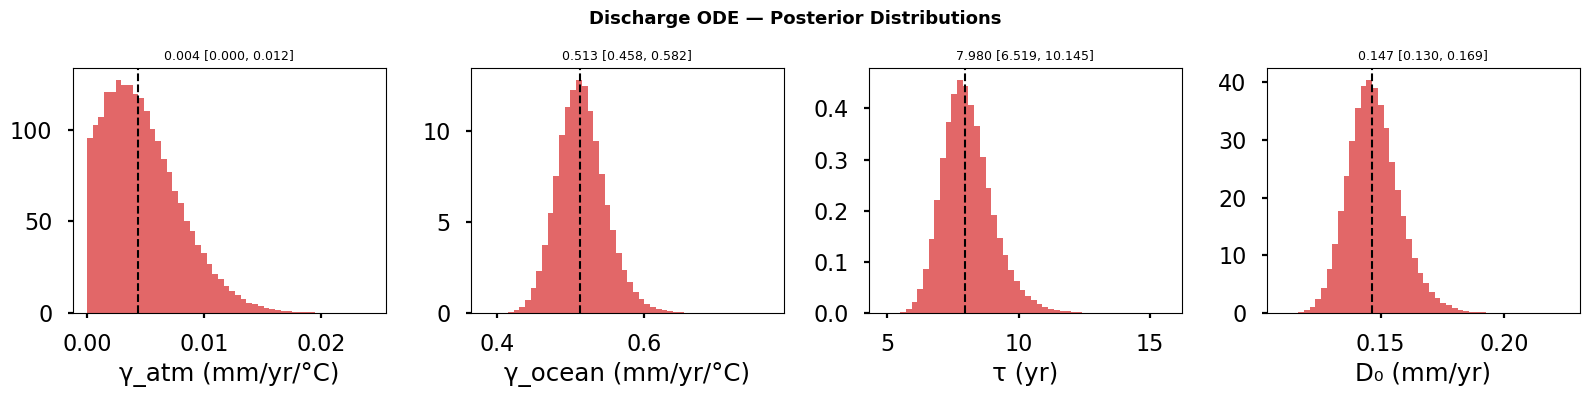

In [5]:
# ── Discharge model posteriors ──
# Four-panel histogram of the ODE model parameters.
# γ_atm near zero confirms ocean forcing dominates decadal discharge variability.
# τ is the e-folding timescale for ocean → grounding-line response.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

params = [
    (result_discharge.gamma_atm_posterior * M_TO_MM, 'γ_atm (mm/yr/°C)'),
    (result_discharge.gamma_ocean_posterior * M_TO_MM, 'γ_ocean (mm/yr/°C)'),
    (result_discharge.tau_posterior, 'τ (yr)'),
    (result_discharge.D0_posterior * M_TO_MM, 'D₀ (mm/yr)'),
]

for ax, (vals, label) in zip(axes, params):
    ax.hist(vals, bins=50, density=True, alpha=0.7, color='C3')
    ax.axvline(np.median(vals), color='k', ls='--', lw=1.5)
    p5, p95 = np.percentile(vals, [3, 97])
    ax.set_xlabel(label)
    ax.set_title(f'{np.median(vals):.3f} [{p5:.3f}, {p95:.3f}]', fontsize=9)

plt.suptitle('Discharge ODE — Posterior Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_discharge_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()

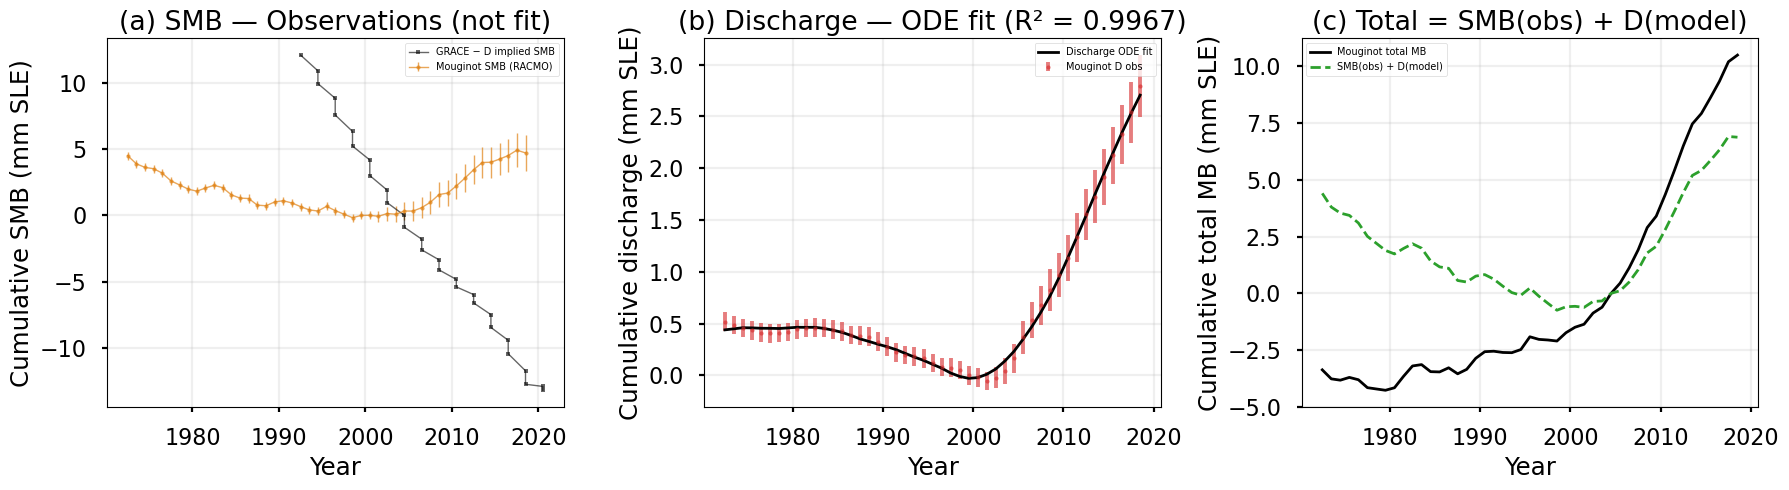

In [6]:
# ── Three-panel diagnostic: SMB, Discharge, and Total mass balance ──
# (a) SMB observations only — not calibrated, passed through as RACMO data
# (b) Discharge ODE fit against Mouginot D, forced by EN4 subsurface ocean T
# (c) Total = SMB(obs) + D(model), validated against Mouginot total MB
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: SMB (observations only — not fit)
ax = axes[0]
ax.errorbar(mou_comp['time_smb'], mou_comp['H_smb'] * M_TO_MM,
            yerr=2 * mou_comp['sigma_smb'] * M_TO_MM,
            fmt='o-', ms=3, lw=1, color=COMP_COLORS['Greenland'], alpha=0.7,
            label='Mouginot SMB (RACMO)')

# Overlay GRACE − D implied SMB as RCM-independent validation
if os.path.exists(grace_d_path):
    df_gd = pd.read_csv(grace_d_path)
    gd_cumul = np.cumsum(df_gd['implied_smb_rate_slr'].values)
    bl_gd = np.argmin(np.abs(df_gd['year'].values - BASELINE_YEAR))
    gd_cumul -= gd_cumul[bl_gd]
    ax.plot(df_gd['year'], gd_cumul * M_TO_MM, 'ks-', ms=3, lw=1, alpha=0.6,
            label='GRACE − D implied SMB')

ax.set_ylabel('Cumulative SMB (mm SLE)')
ax.set_xlabel('Year')
ax.set_title('(a) SMB — Observations (not fit)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

# Panel B: Discharge (calibrated ODE model)
ax = axes[1]
ax.errorbar(mou_comp['time_dyn'], mou_comp['H_dyn'] * M_TO_MM,
            yerr=2 * mou_comp['sigma_dyn'] * M_TO_MM,
            fmt='o', ms=3, color='C3', alpha=0.6, label='Mouginot D obs')
ax.plot(mou_comp['time_dyn'], result_discharge.H_dyn_model * M_TO_MM,
        'k-', lw=2, label='Discharge ODE fit')
ax.set_ylabel('Cumulative discharge (mm SLE)')
ax.set_xlabel('Year')
ax.set_title(f'(b) Discharge — ODE fit (R² = {result_discharge.r2_dyn:.4f})')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

# Panel C: Total = observed SMB + modeled discharge
ax = axes[2]
mou_total = read_mouginot2019_greenland(f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_yr = mou_total['decimal_year'].values.astype(float)
mou_cumul = mou_total['cumulative_mb'].values  # m SLE, SLR convention
bl_m = np.argmin(np.abs(mou_yr - BASELINE_YEAR))
mou_cumul -= mou_cumul[bl_m]
ax.plot(mou_yr, mou_cumul * M_TO_MM, 'k-', lw=2, label='Mouginot total MB')

# Interpolate SMB onto D time grid to form model total
smb_on_dyn = np.interp(mou_comp['time_dyn'], mou_comp['time_smb'], mou_comp['H_smb'])
total_model = smb_on_dyn + result_discharge.H_dyn_model
bl_t = np.argmin(np.abs(mou_comp['time_dyn'] - BASELINE_YEAR))
total_model -= total_model[bl_t]
ax.plot(mou_comp['time_dyn'], total_model * M_TO_MM, 'C2--', lw=2,
        label='SMB(obs) + D(model)')
ax.set_ylabel('Cumulative total MB (mm SLE)')
ax.set_xlabel('Year')
ax.set_title('(c) Total = SMB(obs) + D(model)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_smb_d_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Projections

**SMB projections:** RCM-derived C_T with inter-RCM structural uncertainty
(C_T = −200 ± 80 Gt/yr/°C GMST, quadratic −50 ± 30 Gt/yr/°C²).
Propagated through MC ensemble via `project_smb_ensemble()`.

**Discharge projections:** Calibrated ODE with projected ocean T from the
surface-to-ocean transfer function. Parametric uncertainty from discharge
posterior (γ_ocean, τ) + transfer function uncertainty (α, β, σ_resid).

**Total:** H_GrIS = H_SMB + H_D, with SMB and D uncertainty combined in
quadrature (independent components).

In [7]:
# ── SSP constants (always needed for downstream plotting) ──
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
PROJ_YEARS = np.arange(1950, 2151, dtype=float)
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}

if RERUN_FITS:
    # ── Load and rebaseline SSP temperature scenarios ──
    # Splice CMIP6 historical + SSP, align to Berkeley Earth observational baseline
    df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
    overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
    hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
    temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
    offset_gmst = hist_bl - temp_bl  # CMIP6 → Berkeley Earth offset

    temp_projections = {}
    proj_monthly_temps = {}
    proj_monthly_times = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset_gmst
        temp_projections[ssp_name] = combined
        # Interpolate to monthly for ODE integration
        t_mon = np.arange(combined['decimal_year'].min(),
                           combined['decimal_year'].max(), 1/12)
        T_mon = np.interp(t_mon, combined['decimal_year'].values,
                           combined['temperature'].values)
        # Splice: observed before cutoff, projected after
        T_full = np.concatenate([temp_monthly, T_mon[t_mon > temp_time_monthly[-1]]])
        t_full = np.concatenate([temp_time_monthly, t_mon[t_mon > temp_time_monthly[-1]]])
        proj_monthly_temps[ssp_name] = T_full
        proj_monthly_times[ssp_name] = t_full

    # ═══════════════════════════════════════════════════════════════
    # SMB projections: ΔḢ_smb = C_T·ΔT + C_T²·ΔT²
    # Uses RCM-derived C_T with inter-RCM structural uncertainty.
    # ═══════════════════════════════════════════════════════════════
    print('Projecting SMB (RCM-derived C_T)...')
    T_proj_annual = {}
    for ssp in PROJ_SSPS:
        df_t = temp_projections[ssp]
        T_proj_annual[ssp] = np.interp(PROJ_YEARS, df_t['decimal_year'].values,
                                        df_t['temperature'].values)

    smb_projections = project_smb_ensemble(
        sensitivity=GREENLAND_SMB,
        T_proj=T_proj_annual,
        time_proj=PROJ_YEARS,
        T_baseline=0.0,  # anomalies relative to 1995–2005
        n_samples=N_SAMPLES,
        seed=600,
    )

    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        med = smb_projections[ssp]['median'][idx_2100] * M_TO_MM
        lo = smb_projections[ssp]['p5'][idx_2100] * M_TO_MM
        hi = smb_projections[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} SMB at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

    # ═══════════════════════════════════════════════════════════════
    # Discharge projections: calibrated ODE with ocean T transfer
    # For each MC sample: draw posterior (γ, τ, D₀) + transfer (α, β),
    # solve ODE forward under projected ocean T, accumulate H_dyn.
    # ═══════════════════════════════════════════════════════════════
    print('\nProjecting discharge (ODE + ocean T transfer)...')
    discharge_projections = {}
    rng_dyn = np.random.default_rng(700)

    # Sub-sample posteriors to N_SAMPLES (posteriors may be larger)
    n_post = len(result_discharge.gamma_ocean_posterior)
    mc_idx = rng_dyn.choice(n_post, size=N_SAMPLES, replace=N_SAMPLES > n_post)

    gamma_atm_draws = result_discharge.gamma_atm_posterior[mc_idx]
    gamma_ocean_draws = result_discharge.gamma_ocean_posterior[mc_idx]
    tau_draws = result_discharge.tau_posterior[mc_idx]
    D0_draws = result_discharge.D0_posterior[mc_idx]
    H0d_draws = result_discharge.H0_dyn_posterior[mc_idx]

    # Transfer function uncertainty propagated per MC sample
    alpha_draws = rng_dyn.normal(ocean_transfer['alpha'],
                                 ocean_transfer['alpha_se'], size=N_SAMPLES)
    beta_draws = rng_dyn.normal(ocean_transfer['beta'],
                                ocean_transfer['beta_se'], size=N_SAMPLES)

    for ssp in PROJ_SSPS:
        T_mon = proj_monthly_temps[ssp]
        t_mon = proj_monthly_times[ssp]

        # Convert GMST → Greenland surface T via Arctic amplification
        T_gr_proj = T_mon * AA
        ssp_start = t_mon[np.searchsorted(t_mon, temp_time_monthly[-1])]

        # Splice observed Greenland T (historical) + projected
        hist_mask_gr = gr_time_monthly < ssp_start
        ssp_mask = t_mon >= ssp_start
        t_full_gr = np.concatenate([gr_time_monthly[hist_mask_gr], t_mon[ssp_mask]])
        T_full_gr = np.concatenate([gr_temp_monthly[hist_mask_gr], T_gr_proj[ssp_mask]])

        # Atmospheric design vectors (I₁ = ∫T dt, I₀ = elapsed time)
        dv = build_level_design_vectors(
            temperature_monthly=T_full_gr, time_monthly=t_full_gr,
            obs_times=PROJ_YEARS)
        I1_proj = dv['I1_obs']
        I0_proj = dv['I0_obs']

        # Historical ocean T for ODE spin-up
        hist_mask_oc = time_ocean_monthly < ssp_start
        oc_hist_t = time_ocean_monthly[hist_mask_oc]
        oc_hist_T = T_ocean_monthly[hist_mask_oc]

        ens_dyn = np.zeros((N_SAMPLES, len(PROJ_YEARS)))

        for i in range(N_SAMPLES):
            # Project ocean T from surface T via transfer function
            T_ocean_proj = alpha_draws[i] * T_gr_proj[ssp_mask] + beta_draws[i]
            t_oc_full = np.concatenate([oc_hist_t, t_mon[ssp_mask]])
            T_oc_full = np.concatenate([oc_hist_T, T_ocean_proj])

            # Solve ODE: dD_eff/dt = (T_ocean − D_eff) / τ
            D_eff, _ = solve_twolayer_ode(T_oc_full, t_oc_full, tau_draws[i], np.inf)
            # Integrate D_eff → cumulative ocean-driven discharge
            dt_oc = np.diff(t_oc_full)
            D_mid = 0.5 * (D_eff[:-1] + D_eff[1:])
            cum_D = np.concatenate([[0], np.cumsum(D_mid * dt_oc)])
            cum_D_proj = np.interp(PROJ_YEARS, t_oc_full, cum_D)

            # H_dyn = γ_atm·I₁ + γ_ocean·∫D_eff + D₀·I₀ + H₀
            H_dyn_i = (gamma_atm_draws[i] * I1_proj
                        + gamma_ocean_draws[i] * cum_D_proj
                        + D0_draws[i] * I0_proj + H0d_draws[i])

            bl_idx = np.argmin(np.abs(PROJ_YEARS - BASELINE_YEAR))
            ens_dyn[i] = H_dyn_i - H_dyn_i[bl_idx]

        discharge_projections[ssp] = {
            'samples': ens_dyn,
            'median': np.median(ens_dyn, axis=0),
            'p5': np.percentile(ens_dyn, 5, axis=0),
            'p17': np.percentile(ens_dyn, 17, axis=0),
            'p83': np.percentile(ens_dyn, 83, axis=0),
            'p95': np.percentile(ens_dyn, 95, axis=0),
        }

        idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
        med = discharge_projections[ssp]['median'][idx_2100] * M_TO_MM
        lo = discharge_projections[ssp]['p5'][idx_2100] * M_TO_MM
        hi = discharge_projections[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} D at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

    # ═══════════════════════════════════════════════════════════════
    # Total Greenland = SMB + Discharge (independent, additive)
    # Independence supported by King (2020), Felikson (2017), and
    # the absence of SMB–discharge correlation in Mouginot per-glacier data.
    # ═══════════════════════════════════════════════════════════════
    print('\nTotal Greenland (SMB + D):')
    greenland_proj = {}
    for ssp in PROJ_SSPS:
        total_samples = smb_projections[ssp]['samples'] + discharge_projections[ssp]['samples']
        greenland_proj[ssp] = {
            'samples': total_samples,
            'median': np.median(total_samples, axis=0),
            'p5': np.percentile(total_samples, 5, axis=0),
            'p17': np.percentile(total_samples, 17, axis=0),
            'p83': np.percentile(total_samples, 83, axis=0),
            'p95': np.percentile(total_samples, 95, axis=0),
            'smb_median': smb_projections[ssp]['median'],
            'dyn_median': discharge_projections[ssp]['median'],
        }

        idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
        med = greenland_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = greenland_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = greenland_proj[ssp]['p95'][idx_2100] * M_TO_MM
        smb_med = smb_projections[ssp]['median'][idx_2100] * M_TO_MM
        dyn_med = discharge_projections[ssp]['median'][idx_2100] * M_TO_MM
        print(f'  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm '
              f'(SMB: {smb_med:.0f}, D: {dyn_med:.0f})')

    # ── Persist posteriors + projections to HDF5 ──
    save_greenland(
        result_discharge=result_discharge,
        smb_sensitivity=GREENLAND_SMB,
        ocean_transfer=ocean_transfer,
        obs_smb_years=mou_comp['time_smb'],
        obs_smb_H=mou_comp['H_smb'],
        obs_smb_sigma=mou_comp['sigma_smb'],
        obs_dyn_years=mou_comp['time_dyn'],
        obs_dyn_H=mou_comp['H_dyn'],
        obs_dyn_sigma=mou_comp['sigma_dyn'],
        greenland_proj=greenland_proj,
        smb_projections=smb_projections,
        discharge_projections=discharge_projections,
        h5_path=RESULTS_H5,
    )

else:
    # ── Load cached projections from HDF5 (fast path) ──
    cached = load_component('greenland', h5_path=RESULTS_H5)
    greenland_proj = cached['projections']
    smb_projections = cached.get('projections_smb', {})
    discharge_projections = cached.get('projections_discharge', {})

    # Still need SSP temperatures for downstream plotting cells
    df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
    overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
    hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
    temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
    offset_gmst = hist_bl - temp_bl

    temp_projections = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset_gmst
        temp_projections[ssp_name] = combined

    print('Loaded cached Greenland projections from HDF5')
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        if ssp in greenland_proj:
            med = greenland_proj[ssp]['median'][idx_2100] * M_TO_MM
            lo = greenland_proj[ssp]['p5'][idx_2100] * M_TO_MM
            hi = greenland_proj[ssp]['p95'][idx_2100] * M_TO_MM
            print(f'  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Projecting SMB (RCM-derived C_T)...
  SSP1-2.6 SMB at 2100: 55 [25, 86] mm
  SSP2-4.5 SMB at 2100: 88 [40, 135] mm
  SSP3-7.0 SMB at 2100: 124 [58, 190] mm
  SSP5-8.5 SMB at 2100: 164 [76, 252] mm

Projecting discharge (ODE + ocean T transfer)...
  SSP1-2.6 D at 2100: 26 [21, 32] mm
  SSP2-4.5 D at 2100: 32 [25, 39] mm
  SSP3-7.0 D at 2100: 36 [29, 45] mm
  SSP5-8.5 D at 2100: 42 [33, 51] mm

Total Greenland (SMB + D):
  SSP1-2.6: 82 [50, 112] mm (SMB: 55, D: 26)
  SSP2-4.5: 120 [72, 166] mm (SMB: 88, D: 32)
  SSP3-7.0: 160 [94, 224] mm (SMB: 124, D: 36)
  SSP5-8.5: 206 [117, 293] mm (SMB: 164, D: 42)
Saved greenland → ../data/processed/component_results.h5  (96663 KB total)


/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:933: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


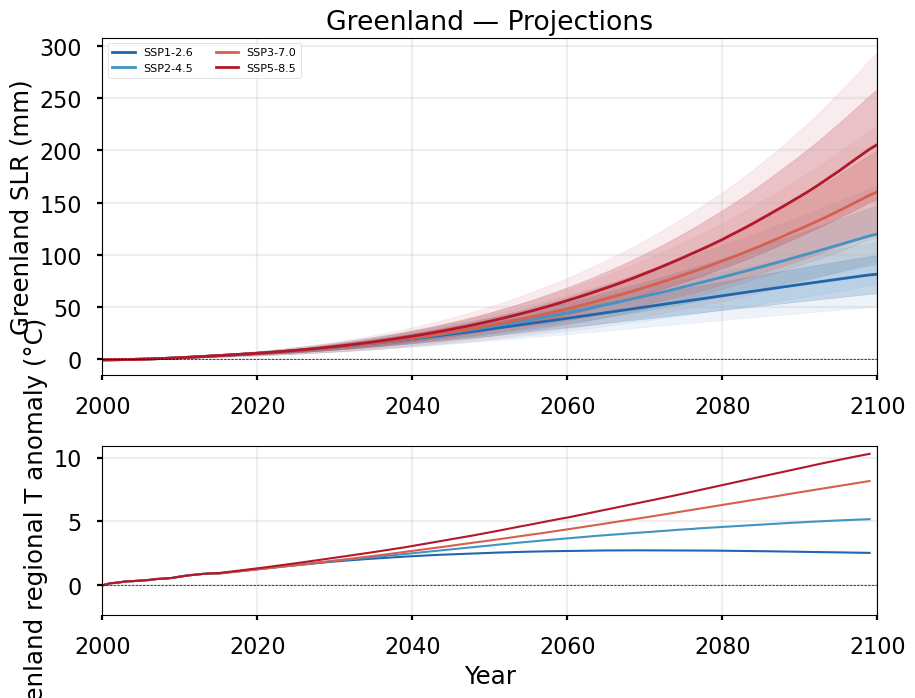

In [8]:
# ── Two-panel projection plot: SLR (top) + Greenland T scenarios (bottom) ──
# Lower panel shows Greenland regional T = GMST × AA to convey the local
# warming that drives both SMB and discharge.
temp_scenarios = {}
for ssp in PROJ_SSPS:
    df_t = temp_projections[ssp]
    ann = df_t.groupby(df_t['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp] = {
        'years': ann['decimal_year'].values,
        'temperature': ann['temperature'].values * AA,
    }

plot_component_projection_twopanel(
    comp_proj=greenland_proj, proj_years=PROJ_YEARS,
    component_name='Greenland',
    temperature_scenarios=temp_scenarios,
    temp_label='Greenland regional T anomaly (°C)',
    ssps=PROJ_SSPS,
    xlim=(2000,2100),
    save_path=f'{FIG_DIR}/component_greenland_twopanel.png',
)

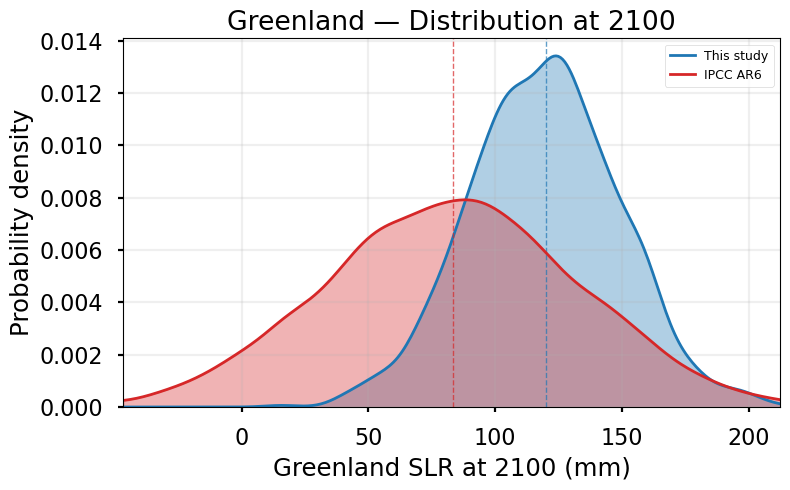

In [9]:
# ── Histogram comparison: this study vs IPCC AR6 at 2100 ──
# IPCC GIS component extracted from AR6 confidence output NetCDFs.
# IPCC percentiles are approximated as Gaussian for histogram overlay.
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'
rng_hist = np.random.default_rng(99)

our_samples = greenland_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245', 'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
ipcc_data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', SSP_CODE[HIST_SSP], 'GIS')
sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if ipcc_data is not None:
    ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ex['years'] - 2100))
    ipcc_med = ex['q50'][yr_idx]
    ipcc_sig = (ex['q95'][yr_idx] - ex['q05'][yr_idx]) / (2 * 1.645)  # 90% CI → σ
    ipcc_samples = rng_hist.normal(ipcc_med, ipcc_sig, 10000)
    sample_sets.append(ipcc_samples)
    labels.append('IPCC AR6')
    colors.append('tab:red')

plot_component_histogram(sample_sets, labels, colors, 'Greenland', year=2100,
                          save_path=f'{FIG_DIR}/component_greenland_histogram_2100.png')

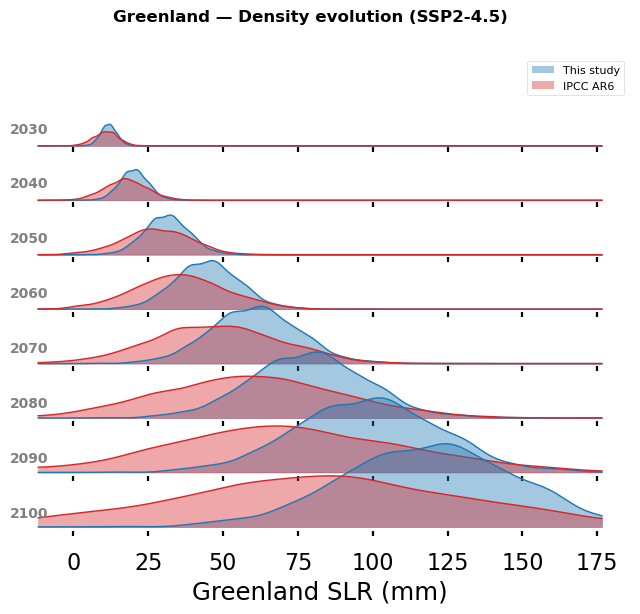

In [10]:
# ── Ridge plot: distribution evolution at decadal intervals (2030–2100) ──
# Shows how the predictive distribution widens over time and how
# our estimates diverge from IPCC AR6 at longer horizons.
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    year_dict = {'This study': greenland_proj[RIDGE_SSP]['samples'][:, idx_yr] * M_TO_MM}
    if ipcc_data is not None:
        ex = ipcc_extract(ipcc_data)
        yr_idx_i = np.argmin(np.abs(ex['years'] - yr))
        if np.abs(ex['years'][yr_idx_i] - yr) < 5:
            ipcc_med_yr = ex['q50'][yr_idx_i]
            ipcc_sig_yr = (ex['q95'][yr_idx_i] - ex['q05'][yr_idx_i]) / (2 * 1.645)
            year_dict['IPCC AR6'] = rng_ridge.normal(ipcc_med_yr, ipcc_sig_yr, N_SAMPLES)
    samples_by_year[yr] = year_dict

plot_component_ridge(samples_by_year, 'Greenland', RIDGE_SSP,
                      source_colors={'This study': 'tab:blue', 'IPCC AR6': 'tab:red'},
                      save_path=f'{FIG_DIR}/component_greenland_ridge.png')

## 5. IPCC Comparison & Hindcast

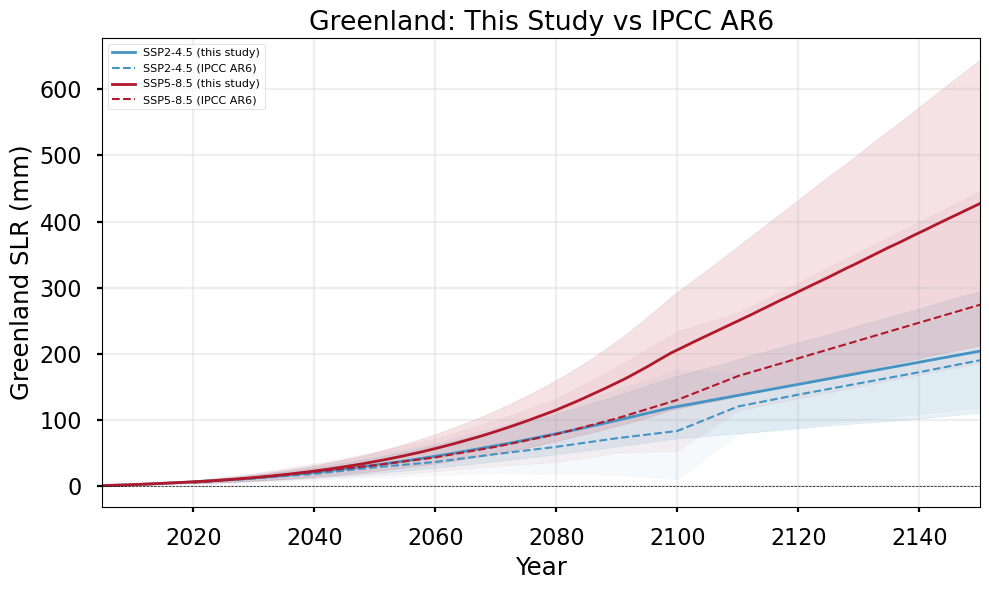

In [11]:
# ── Time-series comparison: this study vs IPCC AR6 GIS component ──
# Solid lines = this study (SMB + D), dashed = IPCC AR6 medium confidence.
# IPCC data in mm (native units from AR6 NetCDFs); our data in m → mm.

fig, ax = plt.subplots(figsize=(10, 6))
proj_mask = PROJ_YEARS >= 2005
yr_plot = PROJ_YEARS[proj_mask]

for ssp in ['SSP2-4.5', 'SSP5-8.5']:
    color = SSP_COLORS[ssp]
    p = greenland_proj[ssp]
    ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2, label=f'{ssp} (this study)')
    ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM, p['p95'][proj_mask] * M_TO_MM,
                    color=color, alpha=0.12)
    # IPCC AR6 overlay
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', SSP_CODE[ssp], 'GIS')
    if ipcc_comp is not None:
        ex = ipcc_extract(ipcc_comp)
        ax.plot(ex['years'], ex['q50'], color=color, ls='--', lw=1.5, label=f'{ssp} (IPCC AR6)')
        ax.fill_between(ex['years'], ex['q05'], ex['q95'], color=color, alpha=0.05)

ax.set_xlabel('Year')
ax.set_ylabel('Greenland SLR (mm)')
ax.set_title('Greenland: This Study vs IPCC AR6')
ax.legend(fontsize=8)
ax.set_xlim(2005, 2150)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_ipcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Appendix: Sensitivity & Reviewer Q&A

### Greenland T vs GMST sensitivity
### Endpoint rate discrepancy
### Taper sensitivity

In [12]:
# ── Sensitivity test: Greenland regional T vs GMST for total mass balance ──
# Fits a linear rate–temperature model (a=0, b·T + c) to Mouginot total MB
# using both Greenland regional T and GMST. Greenland T should give higher R²
# because SMB and discharge respond to local climate, not global mean.
from component_analysis import apply_sigma_taper, restrict_and_fit

df_mou = read_mouginot2019_greenland(f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_year = df_mou['decimal_year'].values
mou_cumul = df_mou['cumulative_mb'].values  # m SLE, SLR convention

OBS_WINDOW = (1972, 2015)
mask_mou = (mou_year >= OBS_WINDOW[0]) & (mou_year <= OBS_WINDOW[1])
yrs_r = mou_year[mask_mou]
H_r = mou_cumul[mask_mou].copy()
bl_r = np.argmin(np.abs(yrs_r - BASELINE_YEAR))
H_r -= H_r[bl_r]  # rebaseline to 2005
sig_r = df_mou['cumulative_mb_sigma'].values[mask_mou]

# Design vectors: I₁ = ∫T dt, I₀ = elapsed time
design_local = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly, time_monthly=gr_time_monthly, obs_times=yrs_r)
design_gmst = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly, obs_times=yrs_r)

# Linear-only fit (I₂ zeroed out to suppress quadratic term)
PRIOR_KW = dict(prior_scale_a=0.010, prior_scale_b=0.01,
                prior_c_mean=0.0003, prior_c_sigma=0.001,
                prior_sigma_extra_scale=0.005, prior_H0_sigma=0.005)

res_local = fit_bayesian_level(
    H_obs=H_r, sigma_obs=sig_r,
    I2_obs=np.zeros_like(design_local['I2_obs']),
    I1_obs=design_local['I1_obs'], I0_obs=design_local['I0_obs'],
    n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=800, **PRIOR_KW)
res_gmst = fit_bayesian_level(
    H_obs=H_r, sigma_obs=sig_r,
    I2_obs=np.zeros_like(design_gmst['I2_obs']),
    I1_obs=design_gmst['I1_obs'], I0_obs=design_gmst['I0_obs'],
    n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=900, **PRIOR_KW)

b_local = np.median(res_local.posterior_samples[:, 1]) * M_TO_MM
b_gmst = np.median(res_gmst.posterior_samples[:, 1]) * M_TO_MM

print(f'Greenland T: b={b_local:.3f} mm/yr/°C, R²={res_local.r2:.4f}')
print(f'GMST:        b={b_gmst:.3f} mm/yr/°C, R²={res_gmst.r2:.4f}')
print(f'→ Greenland regional T provides better fit, consistent with physical expectation.')

Bayesian level-space fit: n=43 observations, ndim=5
  Priors: a~Exp(mean=10.00 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.350, c=0.478 mm/yr, σ_extra=0.67 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 819.24it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.008  ESS_bulk=239  ESS_tail=518
    alpha0: R-hat=1.003  ESS_bulk=285  ESS_tail=767
    trend: R-hat=1.006  ESS_bulk=286  ESS_tail=684
    log_sigma_extra: R-hat=1.015  ESS_bulk=253  ESS_tail=307
    H0: R-hat=1.012  ESS_bulk=262  ESS_tail=718
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=10.415, b=0.357, c=0.470 mm/yr
  σ_extra: median=0.30 mm [0.04, 0.57]
  R² = 0.9570,  acceptance = 0.50
Bayesian level-space fit: n=43 observations, ndim=5
  Priors: a~Exp(mean=10.00 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=1.193, c=0.415 mm/yr, σ_extra=0.67 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 809.81it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.032  ESS_bulk=149  ESS_tail=356
    alpha0: R-hat=1.008  ESS_bulk=253  ESS_tail=541
    trend: R-hat=1.009  ESS_bulk=246  ESS_tail=564
    log_sigma_extra: R-hat=1.021  ESS_bulk=156  ESS_tail=164
    H0: R-hat=1.012  ESS_bulk=227  ESS_tail=496
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=10.076, b=0.590, c=0.309 mm/yr
  σ_extra: median=0.36 mm [0.04, 0.80]
  R² = 0.9027,  acceptance = 0.49
Greenland T: b=0.357 mm/yr/°C, R²=0.9570
GMST:        b=0.592 mm/yr/°C, R²=0.9027
→ Greenland regional T provides better fit, consistent with physical expectation.
